In [2]:
# %pip install --upgrade plotly

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# This might be helpful:
from collections import Counter

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

In [5]:
df = pd.read_csv('2026-06-25-washington-post-police-shootings-export.csv')

# Fatal Force in America: A Data Analysis of Washington Post's Police Shooting Records (2015–2024)

## Preliminary Data Exploration

.shape, the number of colums and rows, and column titles

In [6]:
# df.shape
print(f'Columns: {df.shape[1]}\nRows: {df.shape[0]}')
print(f'Column titles: {df.columns}')

Columns: 12
Rows: 10430
Column titles: Index(['date', 'name', 'age', 'gender', 'armed', 'race', 'city', 'state',
       'flee', 'body_camera', 'signs_of_mental_illness',
       'police_departments_involved'],
      dtype='str')


In [7]:
# df.isnull().sum()

In [8]:
# df.duplicated().sum()

## Dataset Sample

In [9]:
def swap_nans_with_zero(dataframe):
    """Replace missing/NaN values in text columns with 'Unknown'"""
    for col in dataframe.columns:
        if dataframe[col].dtype == 'object':
            dataframe[col] = dataframe[col].fillna('Unknown')
            dataframe[col] = dataframe[col].replace('NaN', 'Unknown')
    return dataframe

swap_nans_with_zero(df)

,date,name,age,gender,armed,race,city,state,flee,body_camera,signs_of_mental_illness,police_departments_involved
0,2015-01-02,Lewis Lee Lembke,47.00,male,gun,White,Aloha,OR,not,False,False,"Washington County Sheriff's Office, OR"
1,2015-01-02,Tim Elliot,53.00,male,gun,Asian,Shelton,WA,not,False,True,"Mason County Sheriff's Office, WA"
2,2015-01-03,John Paul Quintero,23.00,male,unarmed,Hispanic,Wichita,KS,not,False,False,"Wichita Police Department, KS"
3,2015-01-04,Kenneth Joe Brown,18.00,male,gun,White,Guthrie,OK,not,False,False,"Oklahoma Highway Patrol, OK"
4,2015-01-04,Michael Rodriguez,39.00,male,other,Hispanic,Evans,CO,not,False,False,"Evans Police Department, CO"
...,...,...,...,...,...,...,...,...,...,...,...,...
10425,2024-12-30,Timothy Woods,26.00,male,gun,Black,Orlando,FL,foot,False,False,"Orlando Police Department, FL"
10426,2024-12-30,NaN,38.00,male,knife,Unknown,Sacramento,CA,NaN,True,True,"Sacramento County Sheriff's Department, CA"
10427,2024-12-30,Kenneth Thaddeus Roberts Jr.,48.00,male,gun,Black,Indianapolis,IN,car,False,False,"Indianapolis Metropolitan Police Department, I..."
10428,2024-12-31,Moses Alik,22.00,male,knife,Unknown,Celina,OH,NaN,False,False,"Mercer County Sheriff's Office, OH"


## Find out a trend in the police killing over time (2015 - 2014)

In [10]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df_monthly = df.groupby(['year', 'month']).size().reset_index(name='count')
df_monthly['year_month'] = pd.to_datetime(df_monthly[['year', 'month']].assign(day=1))
# print(df_monthly)

Trend slope : +0.158 deaths/month
Overall mean: 86.9 deaths/month
Highest month: May 2024 (126 deaths)
Lowest month : Sep 2018 (59 deaths)


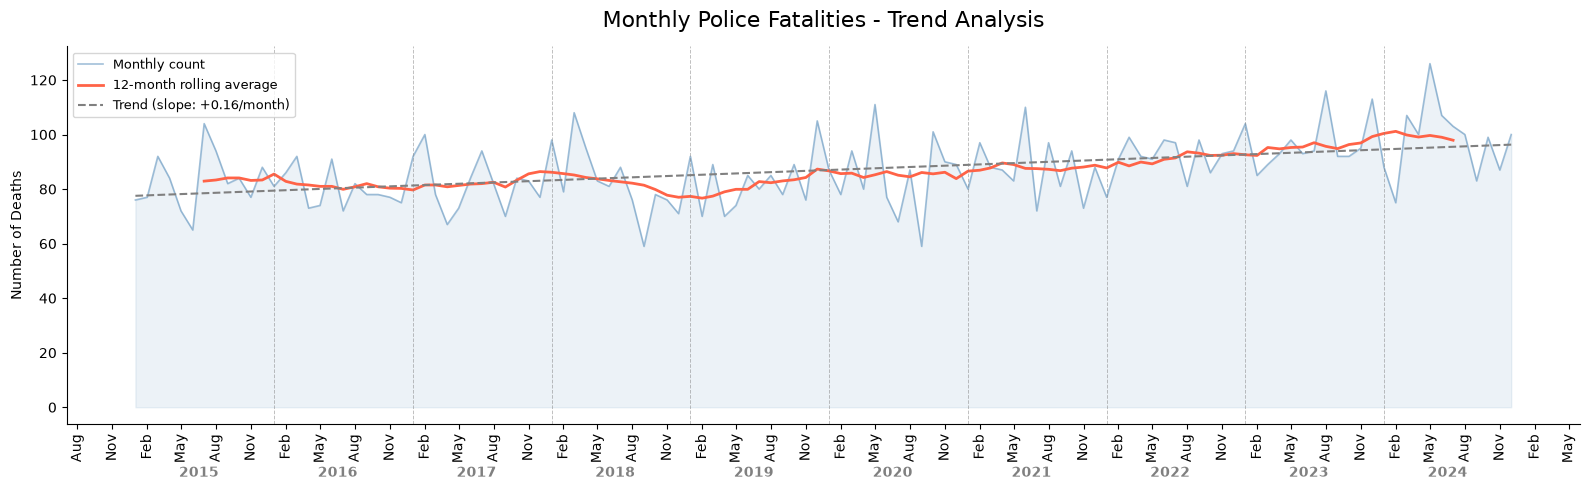

In [11]:
import matplotlib.dates as mdates

df_monthly['x_idx'] = range(len(df_monthly))

z = np.polyfit(df_monthly['x_idx'], df_monthly['count'], 1)
p = np.poly1d(z)
trend = p(df_monthly['x_idx'])

df_monthly['rolling_12'] = df_monthly['count'].rolling(window=12, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    df_monthly['year_month'],
    df_monthly['count'],
    color='steelblue',
    linewidth=1.2,
    alpha=0.5,
    label='Monthly count'
    )
ax.fill_between(
    df_monthly['year_month'],
    df_monthly['count'],
    alpha=0.1, 
    color='steelblue'
)

ax.plot(
    df_monthly['year_month'], 
    df_monthly['rolling_12'],
    color='tomato',
    linewidth=2,
    label='12-month rolling average'
)

ax.plot(
    df_monthly['year_month'],
    trend,
    color='grey',
    linewidth=1.5,
    linestyle='--',
    label=f'Trend (slope: {z[0]:+.2f}/month)'
    )

ax.set_title(
    'Monthly Police Fatalities - Trend Analysis',
    fontsize=16,
    pad=14
    )
ax.set_xlabel('')
ax.set_ylabel('Number of Deaths')
ax.legend(fontsize=9)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.tick_params(axis='x', rotation=90)
ax.spines[['top', 'right']].set_visible(False)

years = df_monthly['year'].unique()
for year in sorted(years):
    year_start = pd.Timestamp(f'{year}-01-01')
    year_end   = pd.Timestamp(f'{year}-12-01')
    year_mid   = year_start + (year_end - year_start) / 2
    if year != min(years):
        ax.axvline(x=year_start, color='grey', linewidth=0.7,
                   linestyle='--', alpha=0.5)
    ax.annotate(
        str(year),
        xy=(year_mid, 0),
        xycoords=('data', 'axes fraction'),
        xytext=(0, -30),
        textcoords='offset points',
        ha='center', va='top',
        fontsize=10, fontweight='bold', color='grey'
    )

# ── Print trend summary ────────────────────────────────────────────────
print(f"Trend slope : {z[0]:+.3f} deaths/month")
print(f"Overall mean: {df_monthly['count'].mean():.1f} deaths/month")
print(f"Highest month: {df_monthly.loc[df_monthly['count'].idxmax(), 'year_month'].strftime('%b %Y')} "
      f"({df_monthly['count'].max()} deaths)")
print(f"Lowest month : {df_monthly.loc[df_monthly['count'].idxmin(), 'year_month'].strftime('%b %Y')} "
      f"({df_monthly['count'].min()} deaths)")

plt.tight_layout()
plt.show()



## Gender Breakdown of US Police Fatalities

In [12]:
df_gender = df.groupby(['gender']).size().reset_index(name='count')
gender_map = {
    'female': 'Female',
    'male' : 'Male',
    'non-binary' : 'Non-binary'
}
df_gender['gender_name'] = df_gender['gender'].map(gender_map)
df_gender = df_gender.sort_values('count', ascending=False)

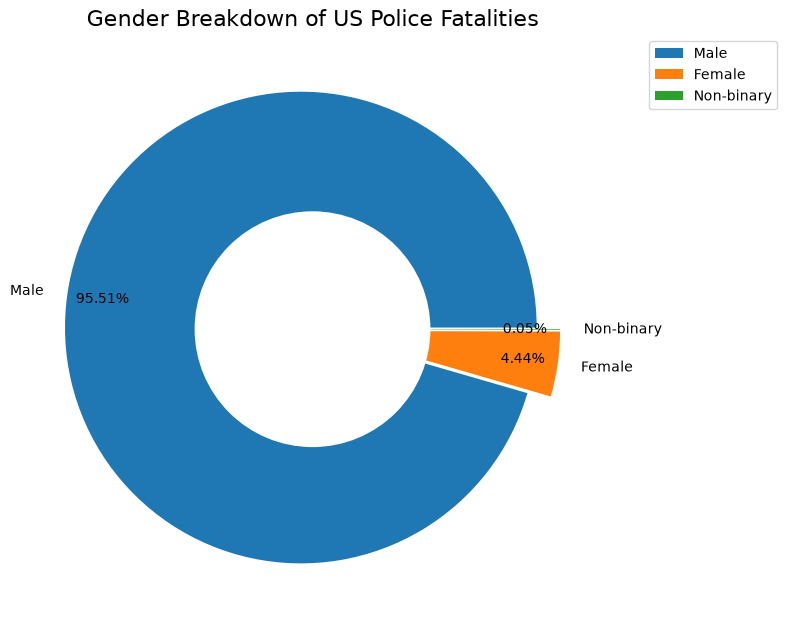

In [13]:
explode = [0.05] * len(df_gender)

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    df_gender['count'],
    labels=df_gender['gender_name'],
    autopct='%1.2f%%',
    pctdistance=0.85,
    explode=explode
)
centre_circle = plt.Circle((0,0), 0.50, fc='white')
ax.add_artist(centre_circle)
ax.set_title(
    "Gender Breakdown of US Police Fatalities",
    fontsize=16,
    fontfamily='DejaVu Sans'
)
plt.legend(
    labels=df_gender['gender_name'],
    loc='upper right',
    bbox_to_anchor=(1.3, 1)
)
plt.tight_layout()
plt.show()


## Age Distribution of Police Fatalities by Gender

In [14]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=age_labels)
df_gender_age = df.groupby(['gender', 'age_group']).size().reset_index(name='count')
df_gender_age['gender_name'] = df_gender_age['gender'].map(gender_map).fillna('Unknown')
# print(df_gender_age)

In [ ]:
import plotly.graph_objects as go

male_data = df_gender_age[df_gender_age['gender'] == 'male']
female_data = df_gender_age[df_gender_age['gender'] == 'female']
non_binary_data = df_gender_age[df_gender_age['gender'] == 'non-binary']

fig = go.Figure()

fig.add_trace(go.Bar(
    x=male_data['age_group'].astype(str),
    y=male_data['count'],
    name='Male',
    marker_color='steelblue'
))

fig.add_trace(go.Bar(
    x=female_data['age_group'].astype(str),
    y=female_data['count'],
    name='Female',
    marker_color='tomato'
))

fig.update_layout(
    barmode='group',
    title='Age Distribution of Fatal Police Encounters by Gender (2015–2024)',
    xaxis_title='Age Group',
    yaxis_title='Number of Deaths',
    template='simple_white',
    legend_title='Gender'
)
fig.show()

<StringArray>
['female', 'male', 'non-binary']
Length: 3, dtype: str
